In [1]:
import os
import matplotlib.pyplot as plt


from sampo_api import contractor
from scripts.wg_converter import WorkGraphConverter, ProjectConverter
from scripts.valid import run_heuristic, resource_profiles, check_feasibility
from scripts.metrics import distance_matrices

from sampo.schemas.graph import WorkGraph


plt.rcParams['axes.grid'] = False

def read_file(path='wgs/small_synth', file='wg_9', contractors_N=5):  
    wg = WorkGraph.loadf(path, file)
    contractors = contractor(N = contractors_N)
    conv = WorkGraphConverter()
    data = conv.convert(wg, contractors)['rcpsp_data']
    return data

# def get_solve(files, base_path, data):

def validate_structures(base_path):
    data = read_file()
    res = []
    files = [f for f in os.listdir(base_path) if f != 'Steps']
    for file in files:
        try:
            schedule, _, resource_usage, job_usage, _  = run_heuristic(base_path, file, data)
            name = (file , file.split(' ')[-1])
        except:
            continue
        if schedule is None or job_usage is None or resource_usage is None:
            continue
        if not check_feasibility(schedule, job_usage, resource_usage, data):
            continue
        resource_profile = resource_profiles(schedule, resource_usage)
        res.append((name, resource_profile, schedule))

    print (f'Originality after test case:  {round( len(res) * 100 / len(files) )} %')
    heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
    D_total = D_contractor + D_interval + D_resource + D_order
    return heuristics, D_contractor, D_interval, D_resource, D_order, D_total

    

Can not find native module; switching to default


Error executing code for method Longest Processing Time Priority Rule (LPT): too many values to unpack (expected 2)
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Earliest Finish Time Priority Rule (EFT): free variable 'compute_duration' referenced before assignment in enclosing scope
Error executing code for method Most Predecessors Priority Rule (MP): Deadlock detected
Error executing code for method Earliest Start Time Priority Rule (EST): rcpsp_solver exceeded 10 second time limit
Originality after test case:  55 %
Originality after matrix filter:  100 %
Acceptable for populations: (LST), (SPT), (GRD), (MS2), (MS1), (LFT).


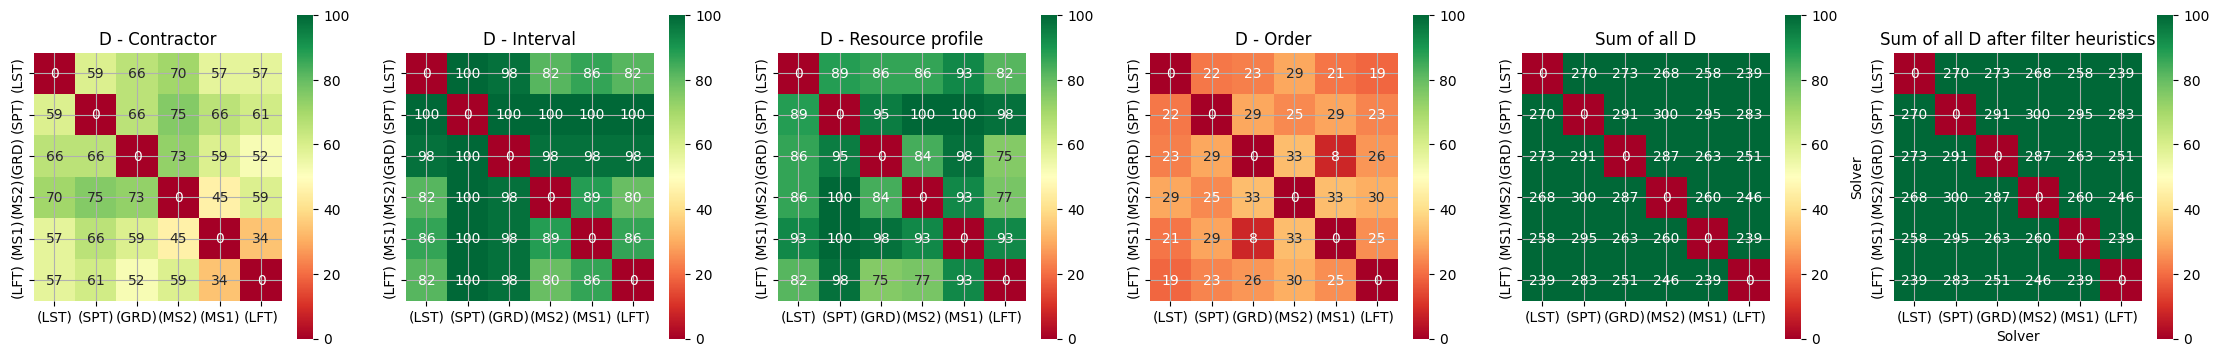

In [90]:
from scripts.valid import *
from collections import defaultdict
from scripts.wg_converter import *
from sampo_api import *
from scripts.metrics import distance_matrices

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json 


def save_filter(path, names):
    with open(os.path.join(path, 'original_heuristics.json'), "w", encoding="utf-8") as f:
        json.dump(names, f, ensure_ascii=False, indent=2)

def plot_heatmap(axes, metrics, labels, orig_labels, 
                 titles = ['D - Contractor', 'D - Interval', 'D - Resource profile', 'D - Order', 
          'Sum of all D', 'Sum of all D after filter heuristics'], vmin=0.0, vmax=100.0):
    for i, metric in enumerate(metrics):
        labels = orig_labels if i == 5 else labels
        sns.heatmap(metric*100, xticklabels=labels, yticklabels=labels, cmap="RdYlGn", 
                    vmin=vmin, vmax=vmax, annot=True, fmt=".0f", square=True, ax=axes[i], 
                    cbar_kws={"shrink": 0.3, "pad": 0.05})
        axes[i].set_title(titles[i])
        plt.xlabel("Solver")
        plt.ylabel("Solver")
def get_filtered_row_indices(D):
    n = D.shape[0]
    # маска внедиагональных элементов
    mask_non_diag = ~np.eye(n, dtype=bool)
    # маска внедиагональных нулей (с учётом float)
    mask_offdiag_zero = D!= 0 & mask_non_diag
    keys = [tuple(row.astype(int)) for row in mask_offdiag_zero]
    seen = set()
    keep = []
    for i in range(n):
        key = keys[i]
        if key not in seen:
            keep.append(i)
            seen.add(key)
    return set(keep)
def estimate_algorithms(D_total, solvers):
    original_idx  = get_filtered_row_indices(D_total)
    original_heuristics = []
    for i, s in enumerate(solvers):
        if i in original_idx:
            original_heuristics.append(s)

    print (f'Originality after matrix filter:  {round( len(original_heuristics) * 100 / len(solvers) )} %')
    print('Acceptable for populations: ' + ', '.join(original_heuristics) +'.')
    return original_idx, original_heuristics


# deepseek_reasoner_control
# Папка для проверок сгенерированных скриптов и сэмпл (проект для теста)
# gpt_oss_120b, deepseek_reasoner, deepseek_chat
base_path = 'Heuristics/claude_haiku_4.5'
heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
idx, original_heuristics = estimate_algorithms(D_total, heuristics)

metrics = (D_contractor, D_interval, D_resource, D_order,
   D_total, D_total[list(idx)][:, list(idx)])

_, axes = plt.subplots(ncols=6, nrows=1, figsize = (28,14) )

plot_heatmap(axes, metrics, heuristics, original_heuristics)

save_filter(base_path, original_heuristics)

# for ax_row in axes: # TODO: nrows > 1
#     plot_heatmap(ax_row, metrics, heuristics, original_heuristics)





In [18]:
original_heuristics

['(LST)', '(SPT)', '(GRD)', '(MS2)', '(MS1)', '(LFT)']

In [19]:
# def validate_structures(base_path):
#     data = read_file()
#     res = []
#     files = [f for f in os.listdir(base_path) if f != 'Steps']
#     for file in files:
#         schedule, _, resource_usage, _  = run_heuristic(base_path, file, data)
#         print(resource_usage)
#         name = file.split(' ')[-1]
#         resource_profile = resource_profiles(schedule,resource_usage)
#         res.append( (name, resource_profile, schedule) )

#     heuristics, D_contractor, D_interval, D_resource, D_order = distance_matrices(res)
#     D_total = D_contractor + D_interval + D_resource + D_order
#     return heuristics, D_contractor, D_interval, D_resource, D_order, D_total


# validate_structures(base_path)

# Проверка 1 - Сравнения LLM-сгенерированных эвристик между собой 
Обозначим множество всех решателей через $S$, а проект через $J$.
Каждому решателю $A \in S$ сопоставлено решение (расписание) по всем
ограничениям и переменным проекта $J$.

Для пары решений $A, B \in S$ введём метрику расстояния $d(A,B)$ как
сумму четырёх компонент:

$$
d(A,B)
=
d_{\text{contractor}}(A,B)
+
d_{\text{interval}}(A,B)
+
d_{\text{resource}}(A,B)
+
d_{\text{order}}(A,B).
$$

Поскольку все решатели рассматривают один и тот же проект $J$, 
множество работ (переменных/активностей) одинаково для всех решений.
Тогда для любой пары решателей $A,B \in S$:

$$
J_A = J_B = J,
\qquad
J_{AB} = J.
$$

1. Доля различий по подрядчикам

$$
d_{\text{contractor}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
c_{A,j} \neq c_{B,j}
\right].
$$

2. Доля различий по интервалам

$$
d_{\text{interval}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\left(t^{\text{start}}_{A,j}, t^{\text{end}}_{A,j}\right)
\neq
\left(t^{\text{start}}_{B,j}, t^{\text{end}}_{B,j}\right)
\right].
$$

3. Доля различий по ресурсным профилям

$$
d_{\text{resource}}(A,B)
=
\frac{1}{| J |}
\sum_{j \in J}
\mathbf{1}\!\left[
\text{res\_profile}_A(j)
\neq
\text{res\_profile}_B(j)
\right].
$$

4. Доля различий по относительному порядку работ (на основе коэффицента Кендалла)

Сначала введём функцию знака:

$$
\operatorname{sgn}(x) =
\begin{cases}
-1, & x < 0,\\
0, & x = 0,\\
1, & x > 0.
\end{cases}
$$

Тогда

$$
d_{\text{order}}(A,B)
=
\frac{1}{\binom{| J |}{2}}
\sum_{\substack{i,j \in J \\ i < j}}
\mathbf{1}\!\left[
\operatorname{sgn}\!\bigl(t^{\text{start}}_{A,i} - t^{\text{start}}_{A,j}\bigr)
\neq
\operatorname{sgn}\!\bigl(t^{\text{start}}_{B,i} - t^{\text{start}}_{B,j}\bigr)
\right].
$$  

1-3 метрики на основе метрики Хэмминга

# Проверка 2 - Сравнения со структурой SAMPO эвристических решателей
# TODO

In [20]:
# TODO, сравнить как по структуре отличается с тем, что выдает SAMPO

# Estimate 0  - GAP с начальной популяцией из SAMPO

In [ ]:
from sampo_api import *
from sampo.scheduler.genetic.operators import TimeFitness
from scripts.valid import *


class Evaluator():
    def __init__(self, work_graph, contractors, f = TimeFitness()):
        self.toolbox = create_mvp_toolbox(work_graph, contractors)
    def makespan(self, chromosome):
        makespan = self.f.evaluate(chromosome, evaluator=self.toolbox.evaluate_chromosome)[0]
        return makespan

        

def estimate_llm_heuristics(filter, base_path, project_conv, data):
    files = [f for f in os.listdir(base_path) if f not in ('Steps', 'original_heuristics.json')]
    makespan_list = []
    for file in files:
        name = file.split(' ')[-1]
        if name not in filter: 
            continue
        schedule, order, _, job_usage, makespan  = run_heuristic(base_path, file, data)

        try:
            chromosome = project_conv.output_to_chromosome(schedule, order, job_usage, makespan)
        except: 

            continue
        if project_conv.is_valid_chromosome(chromosome):
            makespan_list.append(makespan)

    return makespan_list


#def compare_sampo()

def estimate_sampo_population(wg, contractors):
    makespan_list = []
    init_choromosome = first_population(wg, contractors)
    toolbox = create_mvp_toolbox(wg, contractors)
    f = TimeFitness()
    for chrom_d in init_choromosome.items():
        (_, (chrom, _, _)) = chrom_d
        fitness = f.evaluate(chrom, evaluator=toolbox.evaluate_chromosome)[0]
        makespan_list.append(fitness)
    makespan_list.sort()
    return makespan_list

def run_experiment(base_path, filter, wg_path='wgs/small_synth'):
    contractors = contractor(N=5)
    result = []
    for f in os.listdir(wg_path):
        row = {}
        wg = WorkGraph.loadf(wg_path, f[:-5])
        data = read_file(file=f[:-5])
        #
        project_conv = ProjectConverter(wg, contractors)
        #

        sampo_population = estimate_sampo_population(wg, contractors)
        llm_population = estimate_llm_heuristics(filter, base_path, project_conv, data)
        #
        row['wg_name'] = f[:-5]
        row['SAMPO_P_min_makespan'] = min(sampo_population)
        row['SAMPO_P_mean_makespan'] = sum(sampo_population) / len(sampo_population)
        row['LLM_feasibility'] = len(llm_population) / len(filter)
        row['LLM_P_min_makespan'] = min(llm_population)
        row['LLM_P_mean_makespan'] = sum(llm_population) / len(llm_population)
        extended_population = sampo_population + llm_population
        row['E_P_min_makespan'] = min(extended_population)
        row['E_P_mean_makespan'] = sum(extended_population) / len(extended_population)
        row['LLM_best'] =  row['LLM_P_min_makespan'] <= row['SAMPO_P_min_makespan']

        result.append(row)
    return result

model_generate = ['gpt_5.4_nano', 
                  'gemini_3_flash_preview',
                  'gpt_oss_120b', 
                  'deepseek_reasoner', 
                  'deepseek_chat',
                  'claude_haiku_4.5']


arr = []

for model in model_generate:
    base_path = os.path.join('Heuristics', model)
    heuristics, D_contractor, D_interval, D_resource, D_order, D_total = validate_structures(base_path)
    print(f'{model}, total generated heuristics: {len(heuristics)} ')
    idx, original_heuristics = estimate_algorithms(D_total, heuristics)
    result = run_experiment(base_path, original_heuristics)
    result_df = pd.DataFrame(result)
    result_df['LLM_used'] = model
    arr.append(result_df)

df = pd.concat(arr)
df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 


    

Error executing code for method Most Critical Path Priority Rule (MCP): Wall-clock time limit exceeded (10 seconds).
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Originality after test case:  55 %
Originality after matrix filter:  100 %
Acceptable for populations: (LPT), (MSP), (PGS), (LSP), (SSGS), (EFT).
Error executing code for method Earliest Finish Time Priority Rule (EFT): Solver exceeded 10s limit
Originality after test case:  90 %
Originality after matrix filter:  100 %
Acceptable for populations: (LPT), (LST), (PGS), (SPT), (GRD), (MSL), (MSN), (EST), (LFT).
No rcpsp_solver function found in the code for method original_heuristics.json
Error executing code for method original_heuristics.json: local variable 'schedule' referenced before assignment
Error executing code for method Minimum Total Float Rule (TF): local variable '_enforce

In [22]:
df

,wg_name,SAMPO_P_min_makespan,SAMPO_P_mean_makespan,LLM_feasibility,LLM_P_min_makespan,LLM_P_mean_makespan,E_P_min_makespan,E_P_mean_makespan,LLM_best,LLM_used,% shift
0,wg_5,72,92.428571,1.0,92,207.666667,72,145.615385,False,gpt_5.4_nano,0.0
1,wg_29,69,91.428571,1.0,71,204.333333,69,143.538462,False,gpt_5.4_nano,0.0
2,wg_13,69,88.428571,1.0,78,224.333333,69,151.153846,False,gpt_5.4_nano,0.0
3,wg_44,68,85.142857,1.0,64,162.666667,64,120.923077,True,gpt_5.4_nano,6.0
4,wg_9,59,92.000000,1.0,70,205.000000,59,144.153846,False,gpt_5.4_nano,0.0
...,...,...,...,...,...,...,...,...,...,...,...
44,wg_26,78,107.285714,1.0,32,96.666667,32,102.384615,True,claude_haiku_4.5,144.0
45,wg_30,78,103.857143,1.0,30,173.000000,30,135.769231,True,claude_haiku_4.5,160.0
46,wg_6,73,94.857143,1.0,37,90.833333,37,93.000000,True,claude_haiku_4.5,97.0
47,wg_10,77,92.000000,1.0,36,92.000000,36,92.000000,True,claude_haiku_4.5,114.0


In [23]:
contractor(N=5)

[Contractor(id='cd613e30-d8f1-6adf-91b7-584a2265b1f5', name=None, workers={'driver': 6 driver, 'fitter': 6 fitter, 'handyman': 8 handyman, 'electrician': 2 electrician, 'manager': 3 manager, 'engineer': 2 engineer}, equipments={}),
 Contractor(id='025b413f-8a9a-021e-a648-a7dd06839eb9', name=None, workers={'driver': 13 driver, 'fitter': 12 fitter, 'handyman': 16 handyman, 'electrician': 4 electrician, 'manager': 6 manager, 'engineer': 4 engineer}, equipments={}),
 Contractor(id='4be03db0-dc25-74bd-b940-67edfe175330', name=None, workers={'driver': 19 driver, 'fitter': 19 fitter, 'handyman': 24 handyman, 'electrician': 6 electrician, 'manager': 9 manager, 'engineer': 6 engineer}, equipments={}),
 Contractor(id='e1fab9d7-8c7e-134f-5dfb-d3d12c4a3698', name=None, workers={'driver': 23 driver, 'fitter': 22 fitter, 'handyman': 31 handyman, 'electrician': 8 electrician, 'manager': 11 manager, 'engineer': 8 engineer}, equipments={}),
 Contractor(id='eb8ac8ce-8a24-5e6b-3313-8131c541013d', name=No

In [24]:
# # wg = WorkGraph.loadf(wg_path, f[:-5])
# # data = read_file(file=f[:-5])
# schedule, order, _, job_usage, makespan  = run_heuristic('Heuristics/gpt_oss_120b', 'Minimum Earliest Start Time Rule (EST)', read_file())

# schedule

# 'cd613e30-d8f1-6adf-91b7-584a2265b1f5' in order

In [25]:
df = pd.concat(arr)

df['% shift'] = np.where(df['LLM_best'] == True, 
                        round(df['SAMPO_P_min_makespan']  * 100/ df['LLM_P_min_makespan']) - 100,
                        0) 

df[df['LLM_best'] == True].groupby('LLM_used')['% shift'].agg(['min', 'max','count'])


# Всего 49 тестовых кейсов

,min,max,count
LLM_used,,,
claude_haiku_4.5,48.0,160.0,49
deepseek_chat,0.0,28.0,14
deepseek_reasoner,0.0,27.0,14
gemini_3_flash_preview,0.0,48.0,12
gpt_5.4_nano,3.0,26.0,7
gpt_oss_120b,0.0,28.0,11


In [26]:
df.groupby('LLM_used').LLM_feasibility.mean() 

LLM_used
claude_haiku_4.5          1.0
deepseek_chat             1.0
deepseek_reasoner         1.0
gemini_3_flash_preview    1.0
gpt_5.4_nano              1.0
gpt_oss_120b              1.0
Name: LLM_feasibility, dtype: float64

In [27]:
df.groupby('LLM_used').LLM_best.mean() * 100

LLM_used
claude_haiku_4.5          100.000000
deepseek_chat              28.571429
deepseek_reasoner          28.571429
gemini_3_flash_preview     24.489796
gpt_5.4_nano               14.285714
gpt_oss_120b               22.448980
Name: LLM_best, dtype: float64

In [28]:
df.groupby('LLM_used')['LLM_P_mean_makespan'].mean()

LLM_used
claude_haiku_4.5          117.462585
deepseek_chat             123.632653
deepseek_reasoner         116.506122
gemini_3_flash_preview    124.655329
gpt_5.4_nano              226.928571
gpt_oss_120b              302.623907
Name: LLM_P_mean_makespan, dtype: float64

In [29]:
df.groupby('LLM_used')['LLM_feasibility'].mean() * 100

LLM_used
claude_haiku_4.5          100.0
deepseek_chat             100.0
deepseek_reasoner         100.0
gemini_3_flash_preview    100.0
gpt_5.4_nano              100.0
gpt_oss_120b              100.0
Name: LLM_feasibility, dtype: float64

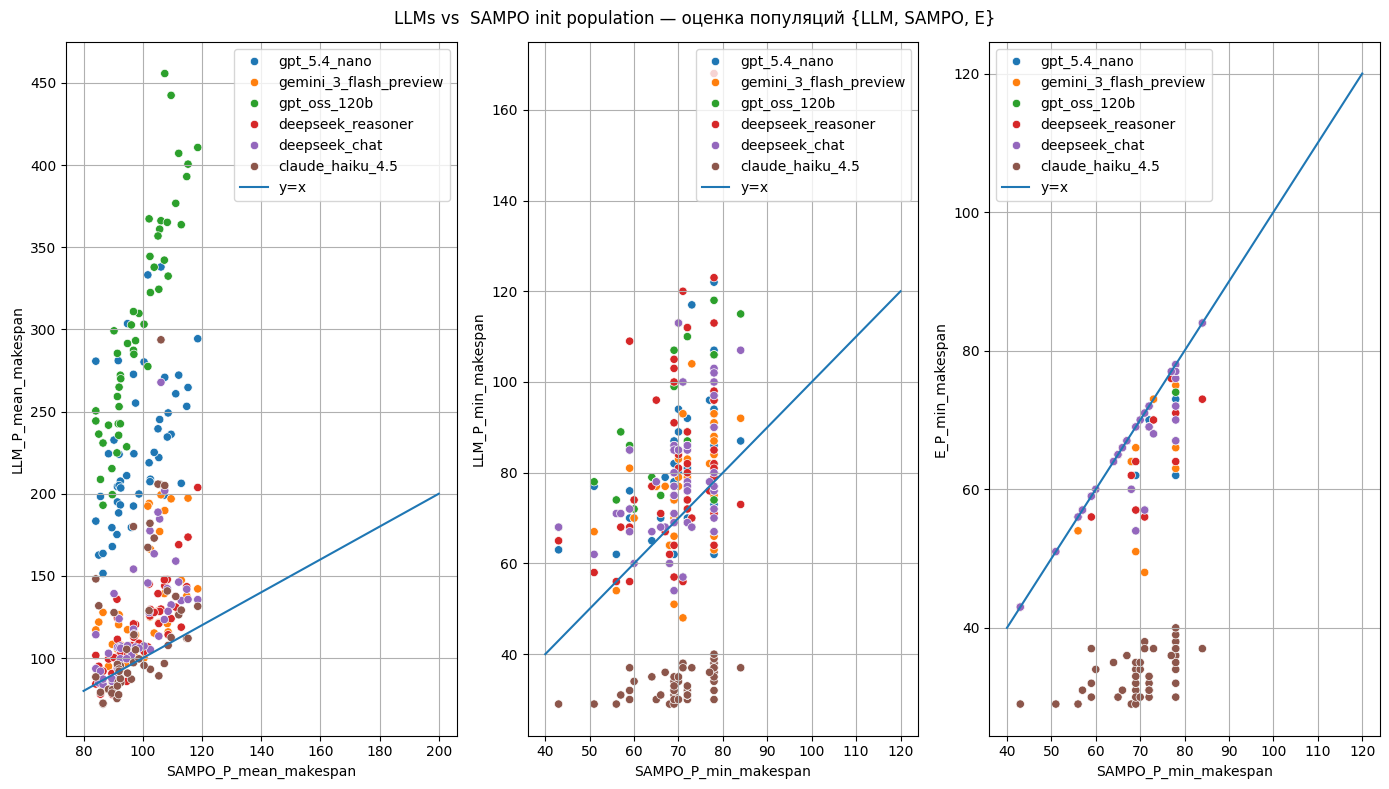

In [30]:
import seaborn as sns
plt.rcParams['axes.grid'] = True
fig, axes = plt.subplots(1, 3, figsize=(14, 8),)

fig.suptitle('LLMs vs  SAMPO init population \u2014 оценка популяций {LLM, SAMPO, E}' )

sns.scatterplot(data=df, x ='SAMPO_P_mean_makespan', y='LLM_P_mean_makespan',hue='LLM_used', ax=axes[0],)
sns.lineplot(x = [80, 200], y =[80, 200], ax=axes[0], label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='LLM_P_min_makespan', hue='LLM_used', ax=axes[1])
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[1],label='y=x')

sns.scatterplot(data=df, x ='SAMPO_P_min_makespan', y='E_P_min_makespan', hue='LLM_used', ax=axes[2],)
sns.lineplot(x = [40, 120], y =[40, 120], ax=axes[2],label='y=x')



plt.tight_layout()

# Time estimate SAMPO vs Gen Heuristics

In [96]:
def estimate_llm_heuristics(filter, wg, 
                            contractors, 
                            base_path, project_conv, data):
    
    init_choromosome = first_population(wg, contractors)
    toolbox = create_mvp_toolbox(wg, contractors)
    f = TimeFitness()

    files = [f for f in os.listdir(base_path) if f not in ('Steps', 'original_heuristics.json')]
    makespan_list = []
    print('Start')
    for file in files:
        name = file.split(' ')[-1]
        if name not in filter: 
            continue
        schedule, order, _, job_usage, makespan  = run_heuristic(base_path, file, data)

        try:
            chromosome = project_conv.output_to_chromosome(schedule, order, job_usage, makespan)
        except: 

            continue
        #print( project_conv.is_valid_chromosome(chromosome) )
        if project_conv.is_valid_chromosome(chromosome):
            fitness = f.evaluate(chromosome, evaluator=toolbox.evaluate_chromosome)[0]
            print(file, makespan, fitness, makespan == fitness)
        else:
            print('not valid')


#'wgs/small_synth', file='wg_9',

# def read_file(path='wgs/small_synth', file='wg_9', contractors_N=5):  
#     wg = WorkGraph.loadf(path, file)
#     contractors = contractor(N = contractors_N)
#     conv = WorkGraphConverter()
#     data = conv.convert(wg, contractors)['rcpsp_data']
#     return data

wg,conts = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=5) 
conv = WorkGraphConverter()
data = conv.convert(wg, conts)['rcpsp_data']

estimate_llm_heuristics(['(MS1)','(MS2)',
                          '(LST)', '(GRD)',
                          '(SPT)'], wg, conts, 'Heuristics/claude_haiku_4.5', ProjectConverter(wg, conts), data)

estimate_llm_heuristics( ['(PGS)','(MSP)','(SSGS)', '(LSP)','(LPT)',], wg, conts, 
                        'Heuristics/gpt_5.4_nano', ProjectConverter(wg, conts), data)




Start
Latest Start Time Priority Rule (LST) 144 144 True
Shortest Processing Time Priority Rule (SPT) 56 326 False
Greatest Resource Demand Priority Rule (GRD) 94 192 False
Most Successors Priority Rule (MS2) 155 155 True
Minimum Slack Priority Rule (MS1) 122 122 True
Start
Longest Processing Time Priority Rule (LPT) 119 119 True
Minimum Slack Priority Rule (MSP) 103 103 True
Parallel Schedule Generation Scheme (PGS) 115 115 True
List Scheduling with Priority Rules (LSP) 183 183 True
Serial Schedule Generation Scheme (SSGS) 1497 1496 False


In [93]:
#'gemini_3_flash_preview'
for model in ('claude_haiku_4.5','gpt_5.4_nano', 'deepseek_chat', 'deepseek_reasoner'):
    base = os.path.join('Heuristics', model)
    with open(os.path.join(base, 'original_heuristics.json'), "r", encoding="utf-8") as f:
            filter = set(json.load(f))
    estimate_llm_heuristics(filter, wg, conts, base, ProjectConverter(wg, conts), data)
    print(filter)

Start
Latest Start Time Priority Rule (LST) 95 95 True
Shortest Processing Time Priority Rule (SPT) 37 211 False
Greatest Resource Demand Priority Rule (GRD) 70 103 False
Most Successors Priority Rule (MS2) 116 116 True
Minimum Slack Priority Rule (MS1) 118 118 True
Latest Finish Time Priority Rule (LFT) 124 124 True
{'(GRD)', '(MS2)', '(SPT)', '(LFT)', '(LST)', '(MS1)'}
Start
Longest Processing Time Priority Rule (LPT) 90 90 True
Minimum Slack Priority Rule (MSP) 95 95 True
Parallel Schedule Generation Scheme (PGS) 124 124 True
List Scheduling with Priority Rules (LSP) 117 117 True
Serial Schedule Generation Scheme (SSGS) 734 734 True
Earliest Finish Time Priority Rule (EFT) 70 70 True
{'(MSP)', '(LSP)', '(LPT)', '(EFT)', '(SSGS)', '(PGS)'}
Start
Longest Processing Time Priority Rule (LPT) 118 118 True
Minimum Slack Priority Rule (MSP) 118 118 True
Most Successors Priority Rule (MSP2) 72 72 True
Minimum Latest Finish Time Priority Rule (LFT2) 101 101 True
Shortest Processing Time Prio

In [61]:
estimate_llm_heuristics(['(MS1)','(MS2)',
                         '(LST)', '(GRD)', '(LFT)',
                         '(SPT)'], wg, conts, 'Heuristics/claude_haiku_4.5', ProjectConverter(wg, conts), data)

Start
(LPT)
Latest Start Time Priority Rule (LST) 95 95 True
Shortest Processing Time Priority Rule (SPT) 37 211 False
Greatest Resource Demand Priority Rule (GRD) 70 103 False
(EFT)
(MP)
Most Successors Priority Rule (MS2) 116 116 True
(EST)
Minimum Slack Priority Rule (MS1) 118 118 True
Latest Finish Time Priority Rule (LFT) 124 124 True


In [62]:

schedule, order, _, job_usage, makespan  = run_heuristic('Heuristics/claude_haiku_4.5', 
                                                         'Shortest Processing Time Priority Rule (SPT)', read_file())

# schedule

# 'cd613e30-d8f1-6adf-91b7-584a2265b1f5' in order

In [ ]:
ProjectConverter(wg, conts).to_schedule(schedule, order, job_usage, makespan)

In [ ]:
# def estimate_sampo_population(wg, contractors):
#     makespan_list = []
#     init_choromosome = first_population(wg, contractors)
#     toolbox = create_mvp_toolbox(wg, contractors)
#     f = TimeFitness()
#     for chrom_d in init_choromosome.items():
#         (_, (chrom, _, _)) = chrom_d
#         fitness = f.evaluate(chrom, evaluator=toolbox.evaluate_chromosome)[0]
#         makespan_list.append(fitness)
#     makespan_list.sort()
#     return makespan_list
